## Alignment

--> found out that the brainspace built in procrust alignment does work, was just reading the wrong part out of the fitted GM
[`gm.aligned_` vs. `gm.gradients_`]
* but with kernel=None filtering is still necessary!

In [4]:
import numpy as np
import os.path as op

from nilearn.connectome import ConnectivityMeasure
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
from nilearn import signal
import pandas as pd
from scipy.sparse.csgraph import connected_components
from utils import fsavTofsav5,cleanTS
from utils import get_basic_mask

mask, labeling_noParcel = get_basic_mask()

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'

In [2]:
sub = '01'
ses = 1
n_components = 3

source_folder = op.join(bids_folder,'derivatives','correlation_matrices')
cm_file = op.join(source_folder,f'sub-{sub}_ses-{ses}_corrMatrix_fsav5_unfiltered.npy')

if op.isfile(cm_file):
    cm = np.load(cm_file)
else:
    print(cm_file)
    print('correlation matrix as to be generated first!!') 

In [30]:
from time import process_time

t = process_time()
target_folder = op.join(bids_folder,'derivatives','gradients')


    #sys.exit()

ref_specification = '_aligned-marg' 

g_ref = np.load(op.join(bids_folder,'derivatives', 'gradients',f'gm_av50_unfiltered{ref_specification}.npy')) # same labeling_noParcel as cm_unfiltered

g_align = GradientMaps(n_components=n_components,alignment='procrustes',kernel='normalized_angle') # defaults: approacch = 'dm', kernel = None
elapsed_time = process_time() - t
print(f'{elapsed_time}: starting fitting')
g_align.fit(cm,reference=g_ref)
elapsed_time = process_time() - t
print(f'{elapsed_time}: finished fitting')

0.551068000000015: starting fitting
3206.520498: finished fitting


In [31]:
gm = g_align.aligned_.T #gradients_.T
print(gm.shape)
g_align.gradients_.T.shape

(3, 18715)


(3, 18715)

In [32]:


grad = [None] * n_components
for i, g in enumerate(gm): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.shape(grad)


(3, 20484)

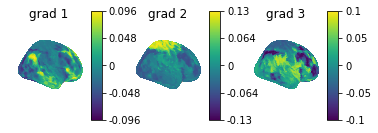

In [34]:
from utils_02 import plot_from_nparray

plot_from_nparray(grad,colorbar=True)

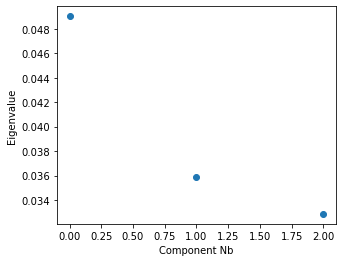

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(5, 4))
ax.scatter(range(g_align.lambdas_.size), g_align.lambdas_)
ax.set_xlabel('Component Nb')
ax.set_ylabel('Eigenvalue')

plt.show()

### without special kernel but filtering

In [5]:
# filter out nodes
from scipy.sparse.csgraph import connected_components

cc = connected_components(cm)
mask_cc = cc[1] == 0 # all nodes in 0 belong to the largest connected component, check #-components in cc[0]
mask[mask == True] = mask_cc # mark nodes not in component 0  as False in mask
print('mask with connected components created')

mask with connected components created


In [6]:
cc.save(op.join(target_folder,f'sub-{sub}_ses-{ses}_connected_components.npy'))

(7, array([0, 0, 0, ..., 0, 0, 0], dtype=int32))

In [58]:
mask, labeling_noParcel = get_basic_mask()
print(mask.shape)
print(mask[mask==True].shape)

print(mask_cc.shape)
print(mask_cc[mask_cc==True].shape)

cm_file = op.join(source_folder,f'sub-{sub}_ses-{ses}_corrMatrix_fsav5_unfiltered.npy')
cm = np.load(cm_file)
print(cm.shape)

(20484,)
(18715,)
(18715,)
(18709,)
(18715, 18715)


In [7]:
ref_specification = '_aligned-marg'

g_ref = np.load(op.join(bids_folder,'derivatives', 'gradients',f'gm_av50_unfiltered{ref_specification}.npy')) # same labeling_noParcel as cm_unfiltered
g_ref = g_ref[mask_cc]

NameError: name 'ref_specification' is not defined

In [64]:

cm_filtered = cm[mask_cc, :][:, mask_cc]

g_align_fil = GradientMaps(n_components=n_components,alignment='procrustes') # defaults: approacch = 'dm', kernel = None
elapsed_time = process_time() - t
print(f'{elapsed_time}: starting fitting')
g_align_fil.fit(cm_filtered,reference=g_ref)
elapsed_time = process_time() - t
print(f'{elapsed_time}: finished fitting')

3273.744729: starting fitting


/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/brainspace-0.1.4-py3.10.egg/brainspace/gradient/embedding.py:70: UserWarning: Affinity is not symmetric. Making symmetric.
  warnings.warn('Affinity is not symmetric. Making symmetric.')


3323.872242: finished fitting


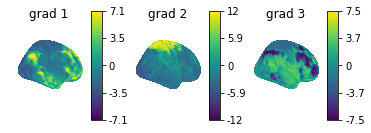

In [66]:
gm = g_align_fil.aligned_.T 
#mask[mask == True] = mask_cc

grad = [None] * n_components
for i, g in enumerate(gm): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.shape(grad)

plot_from_nparray(grad,colorbar=True)


In [67]:
g_ref.shape

(18709, 3)

In [ ]:
gradients = g_align.aligned_  # has now both, gm.gradients_ and gm.aligned_
np.save(op.join(target_folder,f'sub-{sub}_ses-{ses}_ref-p-align_fsav5_unfiltered{ref_specification}.npy'),gradients) # 


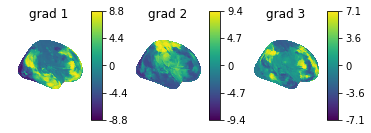

In [18]:
from utils_02 import plot_from_nparray
file = '/Volumes/mrenkeED/data/ds-stressrisk/derivatives/gradients/sub-57/ses-1/gradients__align-procrustes.npy'
grad = np.load(file)
plot_from_nparray(grad,colorbar=True)


In [6]:
atlas = datasets.fetch_atlas_surf_destrieux()
regions = atlas['labels'].copy()
masked_regions = [b'Medial_wall', b'Unknown']
masked_labels = [regions.index(r) for r in masked_regions]
for r in masked_regions:
    regions.remove(r)
labeling = np.concatenate([atlas['map_left'], atlas['map_right']])
labeling_noParcel = np.arange(0,len(labeling),1,dtype = int)     # Map gradients to original parcels
mask = ~np.isin(labeling, masked_labels) # generate a new, raw mask for each sub, that can be worked on later


In [8]:
space='fsnative'
runs = range(1, 7)#,space = 'fsaverage5', bids_folder='/Users/mrenke/data/ds-stressrisk'):
# load in data as timeseries and regress out confounds (for each run sepeprately)
number_of_vertex = 20484  # 'fsaverage5', 10242 * 2

fmriprep_confounds_include = ['global_signal', 'dvars', 'framewise_displacement', 'trans_x',
                            'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z',
                            'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'cosine00', 'cosine01', 'cosine02'
                            ] # 

clean_ts_runs = np.empty([number_of_vertex,0])

ex_file = op.join(bids_folder,'derivatives', 'fmriprep', f'sub-{sub}', f'ses-{ses}', 'func', 
    f'sub-{sub}_ses-{ses}_task-risk_run-1_space-{space}_hemi-L_bold.func.gii')



In [9]:
timeseries = [None] * 2

for i, hemi in enumerate(['L', 'R']):
    ex_file = op.join(bids_folder,'derivatives', 'fmriprep', f'sub-{sub}', f'ses-{ses}', 'func', 
    f'sub-{sub}_ses-{ses}_task-risk_run-1_space-{space}_hemi-L_bold.func.gii')

    timeseries[i] = nib.load(ex_file).agg_data()
timeseries = np.vstack(timeseries) # (20484, 135)

In [14]:
number_of_vertex = timeseries.shape[0]

    # loop over runs and concatenate timeseries
clean_ts_runs = np.empty([number_of_vertex,0])
for run in runs:
    timeseries = [None] * 2
    for i, hemi in enumerate(['L', 'R']):
        filename = op.join(bids_folder,'derivatives', 'fmriprep', f'sub-{sub}', f'ses-{ses}', 'func', 
        f'sub-{sub}_ses-{ses}_task-risk_run-{run}_space-{space}_hemi-{hemi}_bold.func.gii')
        
    
        timeseries[i] = nib.load(filename).agg_data()
    timeseries = np.vstack(timeseries) # (20484, 135)
    print(timeseries.shape)

    fmriprep_confounds_file = op.join(bids_folder,'derivatives', 'fmriprep', f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-{run}_desc-confounds_timeseries.tsv')
    fmriprep_confounds = pd.read_table(fmriprep_confounds_file)[fmriprep_confounds_include] 
    fmriprep_confounds= fmriprep_confounds.fillna(method='bfill')

    #clean_ts_list[run] = signal.clean(timeseries.T, confounds=fmriprep_confounds).T
    clean_ts = signal.clean(timeseries.T, confounds=fmriprep_confounds).T

    clean_ts_runs = np.append(clean_ts_runs, clean_ts, axis=1)



(256422, 135)
(256422, 135)
(256422, 135)
(256422, 135)
(256422, 135)
(256422, 135)


In [15]:
clean_ts_runs.shape

(256422, 810)

In [18]:
seed_ts_noParcel = clean_ts_runs
correlation_measure_noParcel = ConnectivityMeasure(kind='correlation')

In [ ]:
graph = correlation_measure_noParcel.fit_transform([seed_ts_noParcel.T])[0] #correlation_matrix_noParcel
cc = connected_components(graph)
mask_cc = cc[1] == 0 # all nodes in 0 belong to the largest connected component, check #-components in cc[0]
